In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("breast-cancer_with_header.csv")

In [5]:
df.head()

,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor_size   286 non-null    object
 4   inv_nodes    286 non-null    object
 5   node_caps    286 non-null    object
 6   deg_malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast_quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


In [7]:
df.describe()

,deg_malig
count,286.000000
mean,2.048951
std,0.738217
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


In [15]:
df.isin(["?"]).sum()

Class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      8
deg_malig      0
breast         0
breast_quad    1
irradiat       0
dtype: int64

In [16]:
df = df.replace("?", pd.NA)
df = df.dropna()

In [17]:
df.columns

Index(['Class', 'age', 'menopause', 'tumor_size', 'inv_nodes', 'node_caps',
       'deg_malig', 'breast', 'breast_quad', 'irradiat'],
      dtype='object')

In [20]:
y = df["Class"].map({
    "no-recurrence-events": 0,
    "recurrence-events": 1
})

X = df.drop("Class", axis=1)

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
model = LogisticRegression(max_iter=1000)

rfe = RFE(
    estimator=model,
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train);

In [27]:
selected_features = X.columns[rfe.support_]
print("Top 5 Selected Features:")
selected_features

Top 5 Selected Features:


Index(['deg_malig', 'age_70-79', 'menopause_lt40', 'tumor_size_10-14',
       'node_caps_yes'],
      dtype='object')

In [28]:
ranking_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfe.ranking_
}).sort_values("Ranking")

ranking_df.head(10)

,Feature,Ranking
0,deg_malig,1
5,age_70-79,1
6,menopause_lt40,1
8,tumor_size_10-14,1
24,node_caps_yes,1
16,tumor_size_5-9,2
30,irradiat_yes,3
14,tumor_size_40-44,4
1,age_30-39,5
29,breast_quad_right_up,6


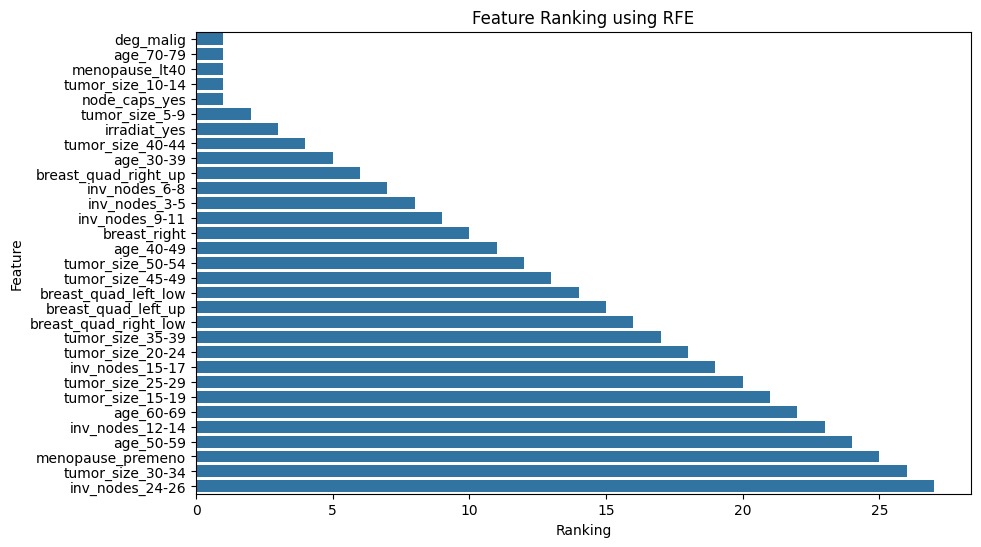

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Ranking", y="Feature", data=ranking_df)
plt.title("Feature Ranking using RFE")
plt.show()

In [31]:
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

model_rfe = LogisticRegression(max_iter=1000)
model_rfe.fit(X_train_rfe, y_train);

In [32]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [33]:
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_scaled, y_train)

all_results = evaluate(model_all, X_test_scaled, y_test)

In [34]:
rfe_results = evaluate(model_rfe, X_test_rfe, y_test)

In [35]:
comparison = pd.DataFrame(
    [all_results, rfe_results],
    index=["All Features", "Top 5 Features"]
)

comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
All Features,0.642857,0.454545,0.263158,0.333333,0.692034
Top 5 Features,0.732143,0.750000,0.315789,0.444444,0.682788


In [36]:
results = {}

for n in [3, 5, 7]:
    rfe = RFE(model, n_features_to_select=n)
    rfe.fit(X_train_scaled, y_train)

    X_train_sel = X_train_scaled[:, rfe.support_]
    X_test_sel = X_test_scaled[:, rfe.support_]

    temp_model = LogisticRegression(max_iter=1000)
    temp_model.fit(X_train_sel, y_train)

    results[f"Top {n} Features"] = evaluate(
        temp_model, X_test_sel, y_test
    )

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Top 3 Features,0.678571,0.526316,0.526316,0.526316,0.671408
Top 5 Features,0.732143,0.750000,0.315789,0.444444,0.682788
Top 7 Features,0.660714,0.500000,0.368421,0.424242,0.692745


Feature selection helps the model focus only on the most important features and removes irrelevant or less useful ones. This can improve model performance by reducing noise and overfitting. When fewer meaningful features are used, the model becomes simpler, faster, and easier to interpret. However, selecting too few features may remove important information, which can slightly reduce accuracy. Therefore, choosing an optimal number of features provides a good balance between performance and simplicity.